Load libraries and the dataset.

In [106]:
import pandas as pd
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

medical_df = pd.read_csv('medical.csv')

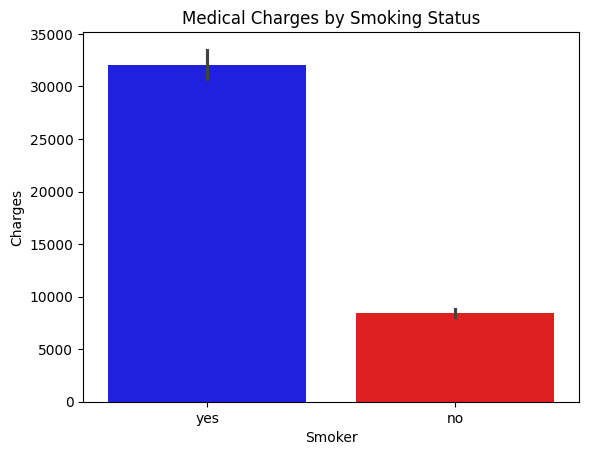

In [107]:
sns.barplot(
    data=medical_df,
    x='smoker',
    y='charges',
    hue='smoker',
    palette=['blue', 'red'],
    legend=False
)

plt.title('Medical Charges by Smoking Status')
plt.xlabel('Smoker')
plt.ylabel('Charges')

plt.show()

Encode smoker so it can be used in regression.

In [108]:
smoker_codes = {'yes': 1, 'no': 0}
medical_df['smoker_code'] = medical_df['smoker'].map(smoker_codes)

In [109]:
medical_df.head()

,age,sex,bmi,children,smoker,region,charges,smoker_code
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0


In [110]:
medical_df.charges.corr(medical_df.smoker_code)

np.float64(0.7872514304984778)

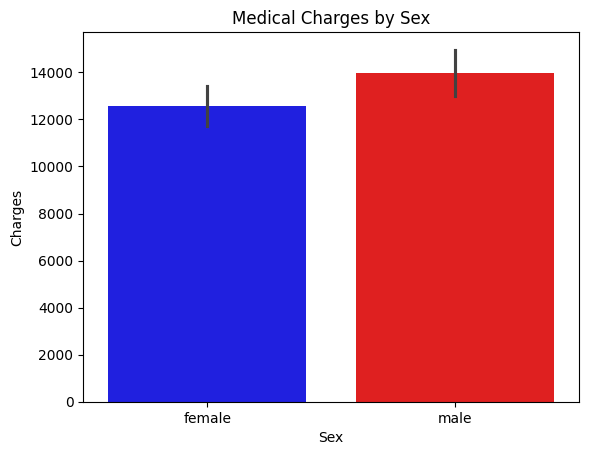

In [111]:
sns.barplot(
    data=medical_df,
    x='sex',
    y='charges',
    hue='sex',
    palette=['blue', 'red'],
    legend=False
)

plt.title('Medical Charges by Sex')
plt.xlabel('Sex')
plt.ylabel('Charges')

plt.show()

Encode sex so it can be used in regression.

In [112]:
sex_code = {'male': 1, 'female': 0}
medical_df['sex_code'] = medical_df['sex'].map(sex_code)

In [113]:
medical_df.charges.corr(medical_df.sex_code)

np.float64(0.05729206220202533)

One Hot encoding

One-hot encode region categories.

C:\Users\mst\AppData\Local\Temp\ipykernel_8988\519781224.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='region', y='charges', data=medical_df, palette='Set2')


<Axes: xlabel='region', ylabel='charges'>

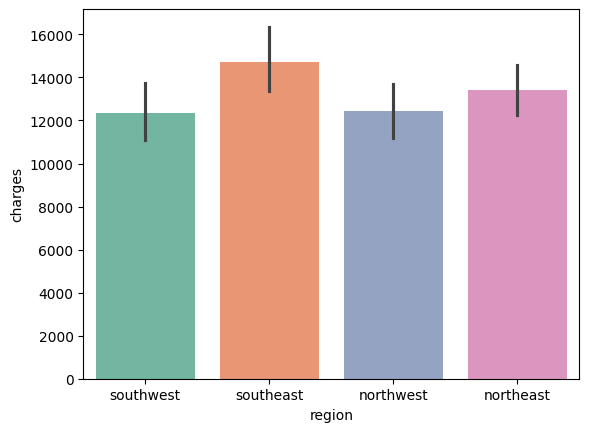

In [114]:
sns.barplot(x='region', y='charges', data=medical_df, palette='Set2')

In [115]:
from sklearn import preprocessing
enc = preprocessing.OneHotEncoder()
enc.fit(medical_df[['region']])
enc.categories_

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [116]:
region_dummies = pd.get_dummies(medical_df['region'])
medical_df = pd.concat([medical_df, region_dummies], axis=1)

Add one-hot columns to the dataframe.

In [117]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

charrges = w1*

Train a model using numeric and categorical features.

In [118]:
input  = medical_df[['age', 'bmi', 'smoker_code', 'sex_code', 'northeast', 'northwest', 'southeast', 'southwest']]
target = medical_df['charges']

model.fit(input, target)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [119]:
predicted_charges = model.predict(input)

Compute an error metric for the fitted model.

In [120]:
def rmse(predictions, actual):
    return np.sqrt(np.mean((predictions - actual) ** 2))

In [121]:
print('w =', model.coef_[0])
print('b =', model.intercept_)
print('RMSE =', rmse(predicted_charges, target))

w = 258.5396974787263
b = -12121.894122921654
RMSE = 6068.68259297263


Visually compare predictions vs actuals.

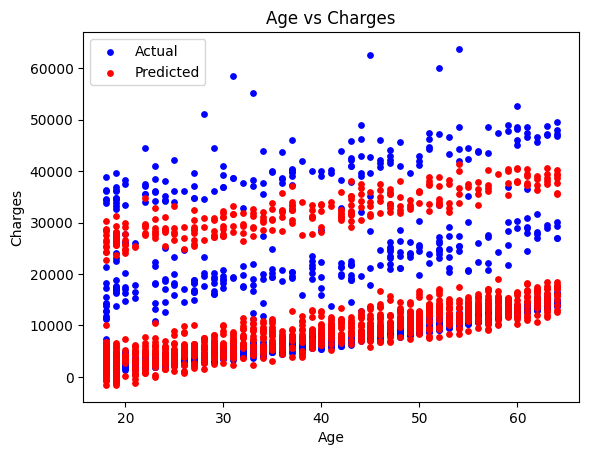

In [122]:
plt.scatter(
    medical_df['age'],
    target,
    color='blue',
    label='Actual',
    s=15
)

plt.scatter(
    medical_df['age'],
    predicted_charges,
    color='red',
    label='Predicted',
    s=15
)

plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Age vs Charges')

plt.legend()
plt.show()

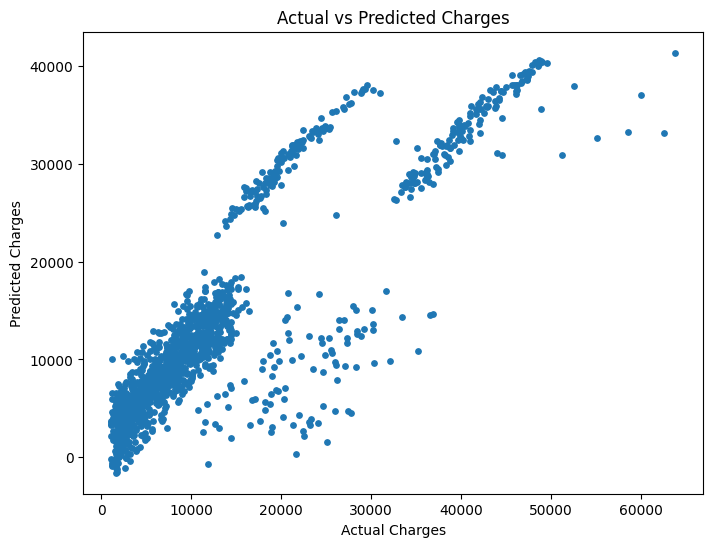

In [123]:
plt.figure(figsize=(8,6))

plt.scatter(target, predicted_charges, s=15)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")

plt.show()